# Scikit-learn — De Estimator & Transformer API

**Scikit-learn** is de standaardbibliotheek voor machine learning in Python. Ze biedt één consistente API voor honderden algoritmes — van preprocessing tot classificatie, regressie en clustering.

Het grote voordeel: je hoeft niet elke bibliotheek apart te leren. Als je de scikit-learn API kent, werkt vrijwel alles op dezelfde manier.

| | Zelf implementeren | Scikit-learn |
|---|---|---|
| Normalisatie | Formules zelf schrijven | `StandardScaler().fit_transform(X)` |
| Train/test splitsing | Handmatig indexeren | `train_test_split(X, y)` |
| Model trainen | Algoritme zelf implementeren | `model.fit(X_train, y_train)` |
| Evalueren | Metriek berekenen | `model.score(X_test, y_test)` |
| Consistentie | Wisselend per algoritme | Altijd dezelfde interface |

Scikit-learn is gebouwd bovenop NumPy en Pandas — data gaat erin als arrays of DataFrames.

In [1]:
import sklearn

print(sklearn.__version__)

1.7.2


## De twee centrale interfaces

Scikit-learn kent twee basisinterfaces die consequent terugkomen:

**Estimator** — leert iets uit data:
- `fit(X, y)` — train het model op de data
- `predict(X)` — maak voorspellingen voor nieuwe data
- `score(X, y)` — evalueer de kwaliteit van de voorspellingen

**Transformer** — zet data om naar een andere representatie (niet te verwarren met Transformers in de context van neurale netwerken):
- `fit(X)` — leer de parameters (bv. gemiddelde en standaardafwijking)
- `transform(X)` — pas de geleerde parameters toe op data
- `fit_transform(X)` — combinatie van beiden (enkel op trainingsdata!)

Veel klassen zijn tegelijk Estimator én Transformer.

## Data voorbereiden

We werken met de **penguins**-dataset: lichaamskenmerken van drie pinguïnsoorten.

In [2]:
import pandas as pd
import seaborn as sns

penguins = sns.load_dataset("penguins").dropna()
print(penguins.shape)
penguins.head()

(333, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [3]:
# Numerical features only (for the first examples)
X_num = penguins[["bill_length_mm", "bill_depth_mm", "flipper_length_mm"]].values
print(X_num[:5])
print("shape:", X_num.shape)

[[ 39.1  18.7 181. ]
 [ 39.5  17.4 186. ]
 [ 40.3  18.  195. ]
 [ 36.7  19.3 193. ]
 [ 39.3  20.6 190. ]]
shape: (333, 3)


## Trainings- en testset

`train_test_split` verdeelt de data willekeurig in een trainingsset (waarmee je leert) en een testset (waarmee je evalueert). De `random_state` zorgt voor reproduceerbaarheid.

In [4]:
from sklearn.model_selection import train_test_split

y = penguins["body_mass_g"].values

X_train, X_test, y_train, y_test = train_test_split(X_num, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (266, 3), Test: (67, 3)


## Transformers — data normaliseren

Veel ML-algoritmes zijn gevoelig voor de schaal van features. Een waarde in millimeter (bv. 180) en één in gram (bv. 4000) bevinden op totaal verschillende schalen — dat heeft een negatieve invloed op het leerproces.

### StandardScaler

**StandardScaler** herschaalt elke feature zodat het gemiddelde 0 is en de standaardafwijking 1.

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit() learns mean and std FROM TRAINING DATA ONLY
scaler.fit(X_train)

print("Learned means:", scaler.mean_.round(2))
print("Learned std:  ", scaler.scale_.round(2))

Learned means: [ 44.1   17.16 201.  ]
Learned std:   [ 5.39  1.98 13.89]


In [ ]:
import numpy as np

# transform() applies the learned parameters to any data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)  # same parameters — NOT fit again!

print(
    f"After scaling — mean: {X_train_scaled.mean(axis=0).round(3)}, std: {X_train_scaled.std(axis=0).round(3)}"
)

After scaling — mean: [-0. -0. -0.], std: [1. 1. 1.]


> **Waarom `fit` enkel op trainingsdata?** Als je ook de testdata gebruikt bij `fit`, lekt informatie van de test naar het leerproces — dit heet *data leakage*. Je testset moet onbekend blijven.

### MinMaxScaler

**MinMaxScaler** schaalt elke feature naar een vaste range (standaard [0, 1]).

In [7]:
from sklearn.preprocessing import MinMaxScaler

mm_scaler = MinMaxScaler()  # default range [0, 1]

X_train_mm = mm_scaler.fit_transform(X_train)  # fit + transform in one step

print(f"min per feature: {X_train_mm.min(axis=0)}")
print(f"max per feature: {X_train_mm.max(axis=0)}")

min per feature: [0. 0. 0.]
max per feature: [1. 1. 1.]


### OneHotEncoder

Categorische features (tekst) kunnen niet rechtstreeks in een ML-model. **OneHotEncoder** zet elke categorie om naar een binaire kolom.

In [8]:
from sklearn.preprocessing import OneHotEncoder

species = penguins[["species"]]  # DataFrame with one column

ohe = OneHotEncoder(sparse_output=False)  # dense matrix output
encoded = ohe.fit_transform(species)

print("Categories:", ohe.categories_)
print("\nEncoded (first 5 rows):")
print(encoded[:5])

Categories: [array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)]

Encoded (first 5 rows):
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [9]:
# Feature names after encoding
print(ohe.get_feature_names_out())

['species_Adelie' 'species_Chinstrap' 'species_Gentoo']


## Estimators — modellen trainen

Een **Estimator** leert een verband tussen input `X` en output `y`. De interface is voor elk model identiek: `fit → predict → score`.

We gebruiken `LinearRegression` enkel als voorbeeld om de interface te demonstreren — het algoritme zelf behandelen we later in de cursus.

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# fit() trains the model — learns the relationship between X and y
model.fit(X_train_scaled, y_train)

print("Trained! Coefficients:", model.coef_.round(1))
print("Intercept:            ", model.intercept_.round(1))

Trained! Coefficients: [ 20.8  19.9 697.9]
Intercept:             4214.8


In [11]:
# predict() returns predictions for new data
y_pred = model.predict(X_test_scaled)

print("First 5 predictions:", y_pred[:5].round(0))
print("Actual values:      ", y_test[:5])

First 5 predictions: [3037. 5255. 3925. 4087. 3761.]
Actual values:       [3250. 4875. 4000. 3675. 4050.]


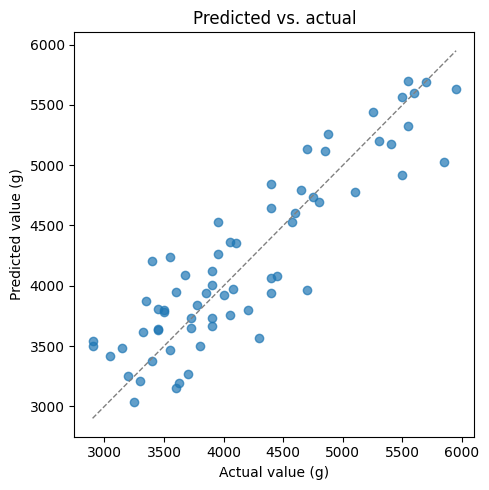

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, y_pred, alpha=0.7)

# Perfect predictions would lie on this diagonal
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, "--", color="gray", linewidth=1)

ax.set_xlabel("Actual value (g)")
ax.set_ylabel("Predicted value (g)")
ax.set_title("Predicted vs. actual")
plt.tight_layout()
plt.show()

In [13]:
# score() returns R² for regression: 1.0 = perfect, 0.0 = no better than mean
r2 = model.score(X_test_scaled, y_test)
print(f"R² on test set: {r2:.3f}")

R² on test set: 0.798


## Geleerde attributen

Na `fit()` slaat scikit-learn de geleerde parameters op als attributen met een **underscore-suffix** (`_`). Dit is een vaste conventie doorheen de hele bibliotheek.

In [14]:
# StandardScaler: learned during fit()
scaler2 = StandardScaler().fit(X_train)
print("mean_: ", scaler2.mean_)
print("scale_:", scaler2.scale_)
print("var_:  ", scaler2.var_)
print("n_samples_seen_:", scaler2.n_samples_seen_)

mean_:  [ 44.10300752  17.1612782  201.        ]
scale_: [ 5.39474737  1.97681217 13.88973765]
var_:   [ 29.10329923   3.90778634 192.92481203]
n_samples_seen_: 266


---

## Oefeningen

**Oefening 1** — Laad de penguins-dataset, verwijder rijen met ontbrekende waarden en maak een train/test-splitsing (80/20) van de numerieke kolommen `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm` en `body_mass_g`. Gebruik `random_state=0`. Druk de shape van elke deelset af.

In [15]:
import seaborn as sns
from sklearn.model_selection import train_test_split
# your solution here

**Oefening 2** — Pas een `StandardScaler` toe op de features uit oefening 1. Fit enkel op de trainingsset en transformeer daarna zowel train als test. Verifieer dat het gemiddelde van de geschaalde trainingsfeatures ≈ 0 is en de standaardafwijking ≈ 1.

In [16]:
from sklearn.preprocessing import StandardScaler
# your solution here

**Oefening 3** — Pas een `MinMaxScaler` toe op dezelfde features zodat alle waarden in [0, 1] liggen. Druk het minimum en maximum per feature af na schaling.

In [17]:
from sklearn.preprocessing import MinMaxScaler
# your solution here

**Oefening 4** — Encodeer de kolom `island` van de penguins-dataset met een `OneHotEncoder`. Druk de kolomnamen af na encoding (`get_feature_names_out()`). Hoeveel kolommen krijg je?

In [18]:
from sklearn.preprocessing import OneHotEncoder
# your solution here

**Oefening 5** — Train een `LinearRegression`-model om `body_mass_g` te voorspellen vanuit de drie geschaalde numerieke features (uit oefening 2). Druk de R²-score op de testset af. Bekijk daarna de geleerde coëfficiënten (`coef_`) — welke feature heeft de grootste impact?

In [19]:
from sklearn.linear_model import LinearRegression
# your solution here